# Detecting Credit Card Fraud with Machine Learning

---
embed-resources: true
echo: false
---

## Introduction

The goal of this report is to describe the results of a model that aims to assist with automatically detecting fraudulent credit card transactions. Methods of fraud include card skimming, account takeovers, and testing stolen cards with small purchases. This prediction system must be quick enough to evaluate the presence of fraud while the transaction is processed.

For fraud in real-time scenarios, there are several key difficulties. Firstly, there are asymmetric costs. Falsely identifying a genuine transaction as fraudulent and missing a fraudulent transaction have undesirable effects that must be considered. Additionally, fraudulent transactions are rare relative to all transactions. This is known as class imbalance, which makes it difficult to balance catching fraud with false alarms. 

## Methods

In [1]:
# imports

# Data Processing / Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ML Preprocessing
from sklearn.preprocessing import (RobustScaler, OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Modeling
from sklearn.metrics import (precision_score, recall_score, accuracy_score, confusion_matrix) 
from sklearn.model_selection import (GridSearchCV, KFold)
from sklearn.metrics import confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from joblib import dump
from sklearn.metrics import make_scorer, fbeta_score


For this report and its associated model, Pandas and NumPy will be used for data handling, Seaborn and Matplotlib will be used for visualization. Various sklearn modules will be used for preprocessing and making the data suitable for machine learning, and also evaluating and visualizing model outcomes. A decision tree model will be used to make predictions, which essentially uses repeated decision making based on boundaries to classify data.

### Data

In [2]:
fraud_train = pd.read_parquet("https://lab.cs307.org/fraud/data/fraud-train.parquet")
fraud_test = pd.read_parquet("https://lab.cs307.org/fraud/data/fraud-test.parquet")


This dataset, originally sourced from Kaggle, contains transactions that occurred over the course of two days. For our purposes, the time variable was removed, the number of samples and class imbalance was reduced, and several variables were renamed. Each row represents a transaction.

**Data Dictionary**

* 'Fraud': boolean variable representing whether the transaction was fraudulent (1) or genuine (0), this is the variable we are trying to predict (target variable)

* 'Amount': dollar amount of transaction

* 'PC01 - PC28': 28 principal components that encode information such as location and type of purchase while preserving customer privacy

In [3]:
samples = len(fraud_train)
features = fraud_train.shape[1]-1
print(f"Samples: {samples}, Features: {features}")

Samples: 54276, Features: 29


In the training dataset, there are 54,276 transactions (samples) and 29 features (variables) we will use to predict the presence of fraud.

In [4]:
fraud_Counts = fraud_train['Fraud'].value_counts()
fraud_Counts_normal = fraud_train['Fraud'].value_counts(normalize=True)
print(fraud_Counts, fraud_Counts_normal)

Fraud
0    53961
1      315
Name: count, dtype: int64 Fraud
0    0.994196
1    0.005804
Name: proportion, dtype: float64


Of the 54,276 transactions, 53,961 are genuine (99.4%) and 315 are fraudulent (0.58%).

In [5]:
agg = fraud_train[['Fraud', 'Amount']].groupby("Fraud").agg(['mean', 'median', 'std', 'max']).reset_index()
agg

Fraud      Amount                             
               mean median         std       max
0     0   88.065104  21.80  241.451144  10199.44
1     1  110.947016   6.99  254.978960   2125.87

We can observe that the mean transaction amount for fraudulent transactions is slightly higher, although the median is lower. 

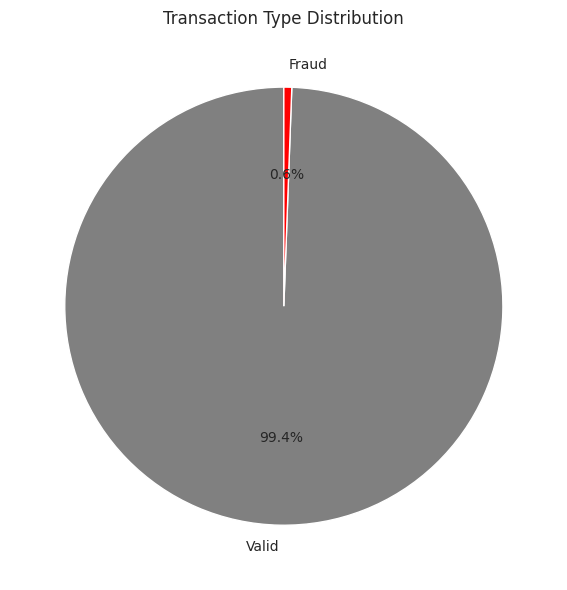

In [6]:

#| fig-cap: "Transaction Type Distribution in Training Dataset"
sns.set_style("white")
plt.figure(figsize=(6, 6))
colors = sns.color_palette("pastel", 4)
plt.pie(
    fraud_train['Fraud'].value_counts(),
    labels=['Valid', 'Fraud'],
    autopct="%1.1f%%",
    startangle=90,
    colors=['gray', 'red'],
    wedgeprops={"edgecolor": "white"}
)

plt.title("Transaction Type Distribution")
plt.tight_layout()
plt.show()


This visualizes the extreme class imbalance between the fraudulent and genuine/valid classes, with 0.6% being fraudulent and 99.4% being genuine.

### Models

In [7]:
# create X and y for train
X_train = fraud_train.drop("Fraud", axis=1)
y_train = fraud_train["Fraud"]

# create X and y for test
X_test = fraud_test.drop("Fraud", axis=1)
y_test = fraud_test["Fraud"]

In order to prepare the data for machine learning, we must separate what we are predicting (target variable "Fraud") from what we are using to predict it (features, everything else). This results in four datasets, each containing the independent and dependent variables for training and testing the model.

In [8]:
# process data for ML

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", RobustScaler()),
    ]
)

# No Categorical Transformer Needed

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_transformer, X_train.columns.tolist()),

    ],
    remainder='drop'
)

pipe = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('estimator', DecisionTreeClassifier())
    ]
)


This creates a procedure to preprocess the independent (feature) data before we put it into the model. Usually, there would be a separate procedure for categorical and numerical data, but in this case we are only using numerical data to predict the dependent (target) variable of transaction type. 

For numeric data, the two main preprocessing steps are imputing (replacing missing values) and scaling (standardizing the data). We create a process of imputing missing values with the median variable value, and scale the data so the mean of every variable is 0 and the standard deviation is one. There are no categorical variables in the feature data so no categorical transformation is needed. In the end, a pipeline of this preprocessing is created along with the decision tree classifier. 

To briefly rehash, a decision tree classifier works by predicting a target class through repeated, boundary based decisions. In the end, this results in an overall pipeline for the model to preprocess and assign the type of model we are using.

In [9]:
c_range = np.geomspace(0.0008, 0.08, num=12)

params = {
    'estimator__max_depth': [2, 4, 8, 12, 16, 20],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__class_weight': [
        None,
        'balanced',
        {0: 1, 1: 1.25},
        {0: 1, 1: 2.5}
    ]
}

metrics = {
    "accuracy_score": "accuracy",
    "recall_score": "recall",
    "precision_score": "precision",
    "f1_metric": "f1"
}

precision_bias_scorer = make_scorer(fbeta_score, beta=0.4)


mod = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    scoring=metrics,
    refit="f1_metric",
    cv=5,
    n_jobs=-1,
    verbose=0
)

When deciding what parameters to test for the model, we create a range of values to test and see which combination has the best results. In 'params', we outline three parameters to tweak:

* 'max_depth': the maximum amount of decisions the model can make before it stops going deeper, testing values of 2, 4, 8, 12, 16 and 20
* 'min_samples_split': the minimum amount of samples left in a group for the model to split it again based on another boundary, testing values of 2, 5 and 10
* 'class_weight': accounts for the class imbalance, testing making no changes, completely balancing the classes, and different ratios

This means that 6x3x4=72 different combinations will be tried. For each combination, the data will be split into fifths, fitted on four fifths, and tested on the remainder fifth. This means that there will be 72x5=360 total fits. These will all be scored on accuracy (proportion of correct predictions), recall (how many fraudulent cases were identified), precision (of predicted fraudulent classes, how many were actually fraud) and f1 (a score that combines precision and recall). For all of these metrics, higher is generally better. The combination that results in the best average f1 score across five fits is selected.

In [10]:
mod.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__class_weight': [None, 'balanced', ...], 'estimator__max_depth': [2, 4, ...], 'estimator__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy_score': 'accuracy', 'f1_metric': 'f1', 'precision_score': 'precision', 'recall_score': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_metric'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbos

After testing all these fits, the best performing model had a max_depth of 4, min_samples_split of 5, and a class weight of {0: 1, 1: 2.5}. This means the best model made at most 4 decisions, had at least 5 samples in group before making another split/decision, and evaluated catching fraud as 2.5x as important as getting a normal case right. Since this combination yielded the best f1 score (balancing precision and recall), this is the combination that is selected.

## Results

In [11]:
# report model metrics
prec = precision_score(y_test, mod.predict(X_test))
rec = recall_score(y_test, mod.predict(X_test))
print(f"Precision Score: {prec}, Recall Score: {rec}")
print(f"Best f1: {mod.best_score_}")
tn, fp, fn, tp = confusion_matrix(y_test, mod.predict(X_test)).ravel()
fpr = fp / (fp + tn)
print(f"Specifity: {fpr*100}%")

Precision Score: 0.9142857142857143, Recall Score: 0.810126582278481
Best f1: 0.8500963011050306
Specificity: 0.04447739065974796%


Our final model tested on unseen data results in a 91.4% precision, 81.0% recall, and 0.85 f1 score. Although these results are strong, catching only 81% of fraudulent transactions is not ideal. In context, this would mean that 91.4% of the transactions the model identifies as fraudulent are fraudulent and that 81% of fraudulent transactions are identified.

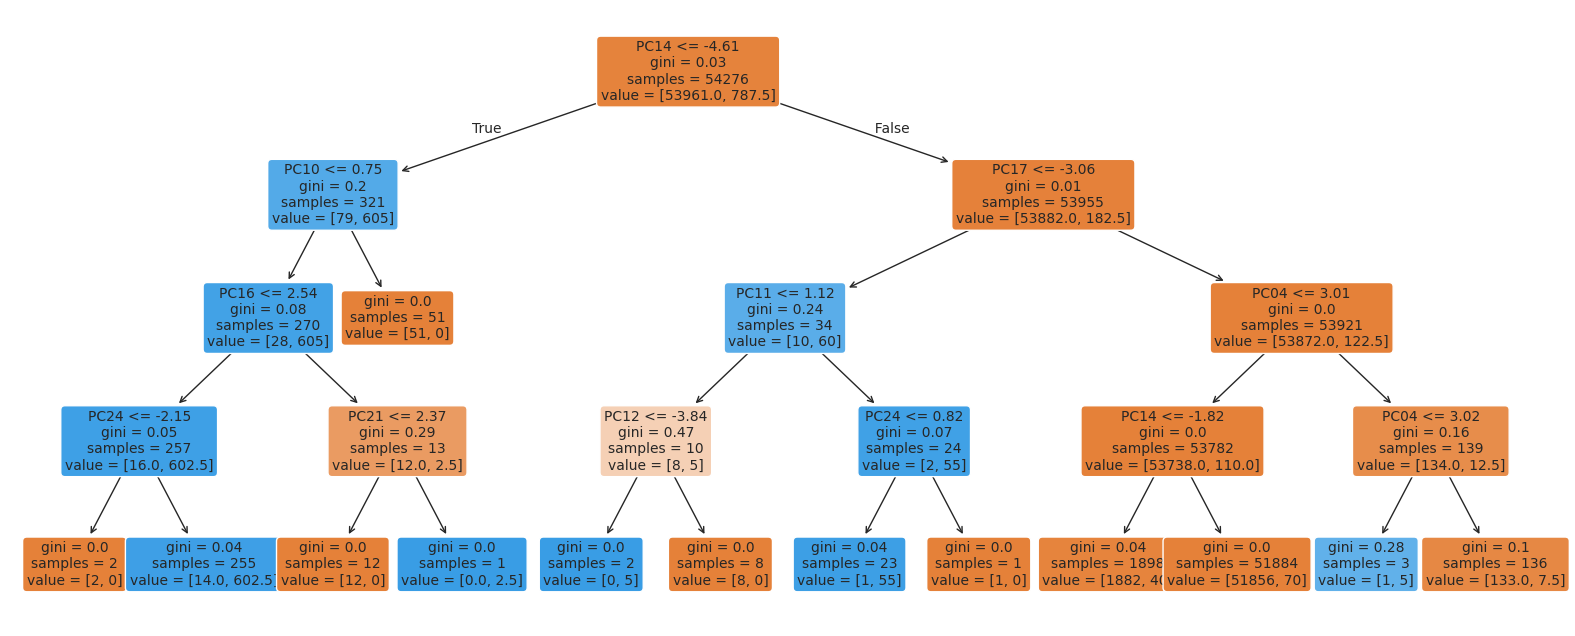

In [12]:
#| fig-cap: "Final Model Decision Making Process Visualized"
best_pipeline = mod.best_estimator_
fitted_tree = best_pipeline[-1]
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
plot_tree(fitted_tree, feature_names=X_train.columns.tolist(), filled=True, rounded=True, fontsize=10, precision=2, ax=ax)
plt.show()

The above chart shows the decision making process that the model uses to predict whether the transaction is fraudulent or genuine. In essence, the model works by repeatedly checking whether certain values are above or below a specified threshold to ascertain the predicted transaction type. This process iterates until there are no decisions left to make and a value is assigned. 

<Figure size 640x480 with 0 Axes>

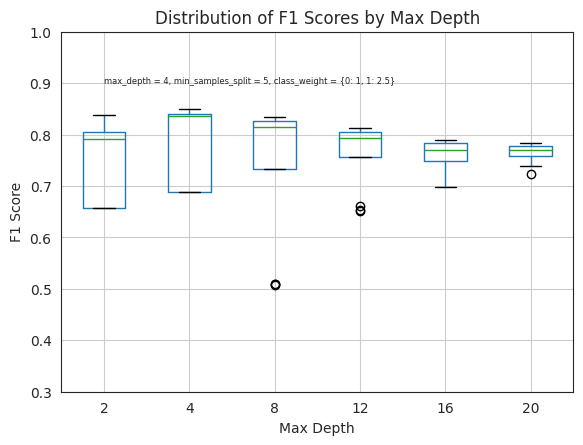

In [13]:
#| fig-cap: "F1 Score Distribution by Max Depth Hyperparameter Value"
results_df = pd.DataFrame(mod.cv_results_)
results_df[['mean_test_f1_metric', 'param_estimator__max_depth']]
plt.figure()

results_df.boxplot(column='mean_test_f1_metric', by='param_estimator__max_depth')

plt.suptitle('')
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.title('Distribution of F1 Scores by Max Depth')
plt.text(1, 0.9, "max_depth = 4, min_samples_split = 5, class_weight = {0: 1, 1: 2.5}", size=6)
plt.ylim(0.3, 1)
plt.show()

This box plot shows the F1 score performance by 'max_depth' parameter. As a reminder, max_depth is how many decisions deep the model can go when predicting the transaction type, and F1 score is just a balance between precision and recall (how many of the fraudulent predictions are right and how many of the actually fraudulent transactions are caught). There are several values for each max_depth value, because there are other parameters it is being combined with, namely 'class_weight' and 'min_samples_split'. 

We can see performance peaks at max_depth of 4, where the best performing model uses min_samples_split of 5 and a class weight of {0: 1, 1: 2.5}. This shows the diminishing returns of increasing the model depth. As the model has a higher 'max_depth', it makes more decisions when predicting the data, which can lead to poorer performance due to overfitting. This is why iterating through several values to find the best combination is important. The peak and dip suggests that the approximate optimal value range has been found.

In [14]:
# serialize model
dump(mod, 'fraud.joblib')                                           

['fraud.joblib']

Finally, we will serialize the model by using the dump() function, making the model sharable.

## Discussion

In conclusion I **would not recommend** using this model without further improvements, depending on the way that the model is applied. Although the model has relatively high precision of 91.4% and a recall of 81.0%, the stakes of the scenario require careful consideration. A recall of 81% means that 19% of fraudulent transactions aren't caught, and a precision of 91.4% means that 8.6% of transactions labeled as fraudulent are genuine. The false positive rate was 0.044%, meaning that 0.044% of genuine transactions were labeled as fraudulent, translating into roughly one of every 2272 transactions. This could lead to frustration for genuine customers when they have their legitimate transactions labeled as fraudulent.

If this were put in place for a large scale credit card company, this is too much error and implementing a system could cause more hassle than benefit, resulting in millions of mistakes spread over millions more transactions. It can be useful if applied in the right way with further improvements. In further development, decreasing the false positive rate and increasing precision and recall should be prioritized. As these metrics improve, the model becomes more reliable and useful for fraud detection.

Ideally, this model can be further developed with more data and parameter tuning to hone in on recall and accuracy, and could be ultimately used as a warning system. Instead of outright blocking transactions based on predicted fraud status, transactions labeled as fraudulent can cause a process where the customer associated with the card is contacted via email and text, warning them of potential fraud. If the user does not recognize the transaction, they can be given concrete steps to fix this and shut down the card. This likely works best because the model is not accurate enough to block transactions but is accurate enough to be useful. Using it as a warning system mitigates the frustration of a false positive while also still being useful. 